# MARCACIÓN CAUSA ATRIBUIBLE SISTEMA SALUD

In [4]:
# =============================================================================
# DEFUNCIONES CONSOLIDADAS - ATRIBUIBILIDAD AL SISTEMA DE SALUD
# Basado en el INIME (Gómez-Arias et al., Rev Panam Salud Publica 26(5), 2009)
# =============================================================================
#
# MARCO CONCEPTUAL
# ─────────────────
# El INIME (Inventario de Indicadores de Mortalidad Evitable) clasifica las
# causas de muerte en grupos según el tipo de intervención que las evitaría:
#
#   Grupo A  →  Evitables por vacunación o tratamiento preventivo
#   Grupo B  →  Evitables por diagnóstico y tratamiento médico precoz
#   Grupo C  →  Evitables por saneamiento ambiental
#   Grupo D  →  Evitables por medidas mixtas (salud + otros sectores)
#   Grupo E  →  Difícilmente evitables en la actualidad
#   Grupo I  →  Causas mal definidas
#   Grupo J  →  Otras causas
#
# CRITERIO DE ATRIBUIBILIDAD AL SISTEMA DE SALUD
# ────────────────────────────────────────────────
# Se considera 1 (atribuible) cuando la causa básica de defunción corresponde
# a los GRUPOS A o B del INIME, es decir, aquellas muertes que podrían
# haberse evitado mediante acciones directas del sistema de salud:
# inmunización, atención preventiva, diagnóstico precoz o tratamiento.
# Los grupos C, D, E, I y J involucran determinantes ambientales, sociales
# o causas no evitables por la medicina, por lo que se marcan con 0.
#
# FUENTE: Cuadro 2 del artículo – códigos CIE-9 (sistema de codificación
# utilizado en la base de defunciones de Colombia).

## 1. IMPORTAR LIBRERIAS Y RUTAS

In [5]:
import pandas as pd
import numpy as np
 
# ── Ruta del dataset en Kaggle ────────────────────────────────────────────────
RUTA_DEFUNCIONES = (
    "/kaggle/input/datasets/nicolasacostaa/"
    "defunciones-causa-ubicacion/"
    "df_limpio_consolidado_defunciones_causa_ubicacion.parquet"
)
RUTA_SALIDA = "/kaggle/working/df_defunciones_atribuibles.parquet"

## 2. FUNCIONES

### 2.1. Definir Códigos CIE-9 Atribuibles a Sistema de Salud

In [6]:
# =============================================================================
# SECCIÓN 1 — CATÁLOGOS CIE-9 Y CIE-10 POR GRUPO INIME
# =============================================================================
# Definición única de todos los sets de códigos usados en el script.
# Las secciones 2, 3 y 4 consumen estos sets directamente.
 
def _expandir_rangos(*items) -> set:
    """
    Expande enteros sueltos o tuplas (ini, fin) a strings de 3 dígitos
    con cero a la izquierda (CIE-9).
    Ejemplo: (10, 18) → {'010', '011', ..., '018'}
    """
    out = set()
    for item in items:
        if isinstance(item, tuple):
            for c in range(item[0], item[1] + 1):
                out.add(str(c).zfill(3))
        else:
            out.add(str(item).zfill(3))
    return out
 
 
def _expandir_cie10(*items) -> set:
    """
    Expande strings sueltos o tuplas ('X00', 'X09') a prefijos CIE-10
    de 3 caracteres (letra + 2 dígitos).
    Ejemplo: ('A20', 'A28') → {'A20', 'A21', ..., 'A28'}
             'B160'         → {'B16'}
    """
    out = set()
    for item in items:
        if isinstance(item, tuple):
            letra = item[0][0]
            for n in range(int(item[0][1:3]), int(item[1][1:3]) + 1):
                out.add(f"{letra}{n:02d}")
        else:
            out.add(item[:3])
    return out
 
 
# ── Grupo A: Vacunación y tratamiento preventivo ──────────────────────────────
_GA_9 = _expandir_rangos(
    (20, 27), (30, 31), 32, 33, 34, 35, 37, 45, 50, 55, 56,
    (90, 99), 390, 392, 393, 398,
    36, 60, 71, 138, 391, (394, 397),          # NC nuevas categorías
)
_GA_10 = _expandir_cie10(
    ('A20','A28'), ('A30','A31'), 'A36', 'A37', 'A38', 'A46',
    ('A33','A34'), 'A80', 'B03', 'B05', 'B06', ('A50','A63'),
    'I00', 'I02', 'I09',
    'A39', 'A95', 'A82', 'B91', 'B16', 'B18', 'B92', 'I01',   # NC
    ('I05','I08'),
)
 
# ── Grupo B: Diagnóstico y tratamiento médico precoz ─────────────────────────
_GB_9 = _expandir_rangos(
    174, 180, 182, 185, 250, (401, 405),
    490, 491, 492, 493, 496,
    (520, 529), 530, (531, 533), 535, (540, 543),
    (550, 553), 560, 562, 564, 567, 572, (574, 575),
    (584, 586), 590, 600,
    38, (410, 414), (417, 429), 424, 428, (430, 438),           # NC
    453, 592, 594, 595, (600, 608), (610, 611),
    (614, 616), (617, 629),
)
_GB_10 = _expandir_cie10(
    'C50', ('C53','C55'), 'C61',
    ('E10','E14'), ('I10','I15'),
    'J40', ('J41','J42'), 'J43', 'J44', 'J45', 'J46', 'J47',
    ('K00','K14'), ('K20','K23'), ('K25','K28'), ('K29','K30'),
    ('K35','K38'), ('K40','K46'), 'K56', 'K57', 'K59',
    ('K80','K83'), 'K65', ('K75','K77'), ('N17','N19'), 'N40',
    ('A40','A41'), ('N80','N83'), ('I60','I69'), ('I20','I25'),  # NC
    'I34', 'I50', 'I82', 'N20', 'N21', 'N30',
    ('N40','N51'), ('N60','N64'), ('N70','N72'),
)
 
# ── Grupo C: Saneamiento ambiental ───────────────────────────────────────────
_GC_9 = _expandir_rangos(
    (1, 9), 70, (80, 83), 85, 86, 100, 139,
)
_GC_10 = _expandir_cie10(
    'A00', 'A01', 'A02', 'A03', 'A05', 'A06', 'A07', 'A08', 'A09',
    'B15', 'A75', ('A77','A79'), ('B56','B57'), 'B55', 'A27', 'B94',
)
 
# ── Grupo D: Medidas mixtas ───────────────────────────────────────────────────
_GD_9 = _expandir_rangos(
    (460, 466), (480, 487),
    (630, 639), (640, 648), (650, 676),
    (760, 779),
    291, 292,
    (800, 999), 303, 304, 305,
    (10, 18), 137,
    (260, 263), 281, 285,
    571,
    61, 84, (120, 130),
    279,
    161, 162,
)
_GD_10 = _expandir_cie10(
    ('J00','J06'), ('J10','J18'), ('J20','J22'),
    ('O00','O08'), ('O10','O16'), ('O20','O21'),
    ('O43','O46'), ('O64','O66'), 'O72', 'O80',
    ('O85','O92'), 'O98', 'O99',
    ('P00','P03'), 'P05', ('P07','P08'), ('P10','P15'),
    ('P20','P21'), ('P22','P28'), ('P35','P39'),
    ('P50','P61'), ('P70','P78'), ('P80','P83'), ('P90','P96'),
    'F10', ('F11','F19'),
    ('V00','V99'), ('W00','W99'), ('X00','X99'), ('Y00','Y98'),
    ('A15','A19'), 'B90',
    ('E40','E46'), ('D50','D53'),
    ('K70','K73'),
    ('A90','A91'), ('B50','B54'), 'B55', ('B65','B83'), 'B58',
    ('B20','B24'),
    'C32', 'C33', 'C34',
)
 
# ── Grupo E: Difícilmente evitables ──────────────────────────────────────────
_GE_9 = _expandir_rangos(
    (140, 173), 175, 181, (183, 209),
    332, 340, 345,
    (415, 416), (420, 423), (425, 427), (429, 430), 440,
    (740, 742), (745, 747),
)
_GE_10 = _expandir_cie10(
    ('C00','C14'), ('C15','C26'), ('C30','C39'), ('C40','C41'),
    ('C43','C44'), ('C45','C47'), ('C48','C49'), ('C51','C52'),
    ('C56','C60'), ('C62','C75'), ('C76','C80'), ('C81','C96'), 'C97',
    'G20', 'G35', 'G40',
    ('I30','I52'), 'I70',
    ('Q00','Q07'), ('Q20','Q28'),
)
 
# ── Grupo I: Causas mal definidas ─────────────────────────────────────────────
_GI_9  = _expandir_rangos((780, 799))
_GI_10 = _expandir_cie10(('R00','R99'))
 
# ── Sets de atribuibilidad (Grupos A+B) usados en Sección 2 ──────────────────
CODIGOS_ATRIBUIBLES_CIE9  = _GA_9  | _GB_9
CODIGOS_ATRIBUIBLES_CIE10 = _GA_10 | _GB_10
 
# ── Mapa completo usado en Sección 4 (prioridad A > B > … > I) ───────────────
_MAPA_GRUPOS = [
    ("A", _GA_9, _GA_10),
    ("B", _GB_9, _GB_10),
    ("C", _GC_9, _GC_10),
    ("D", _GD_9, _GD_10),
    ("E", _GE_9, _GE_10),
    ("I", _GI_9, _GI_10),
]
 
 
def _prefijo_y_sistema(serie: pd.Series):
    """
    Dado una Serie con códigos CIE-9 o CIE-10, devuelve:
      - prefijo (Serie de str de 3 chars)
      - es_cie10 (Serie bool)
 
    CIE-9  → código completamente numérico → zfill(4) → primeros 3 dígitos
    CIE-10 → código inicia con letra       → primeros 3 caracteres
    """
    cod      = serie.astype(str).str.strip().str.upper()
    es_cie10 = cod.str[0].str.isalpha()
    prefijo  = pd.Series("", index=serie.index, dtype="str")
    prefijo[~es_cie10] = cod[~es_cie10].str.zfill(4).str[:3]
    prefijo[ es_cie10] = cod[ es_cie10].str[:3]
    return prefijo, es_cie10
 

### 2.2. Cargar datos

In [7]:
def cargar_datos(ruta: str) -> pd.DataFrame:
    """
    Carga el archivo parquet con las defunciones consolidadas
    ya cruzadas con DIVIPOLA y Lista 105.
 
    Parameters
    ----------
    ruta : str
        Ruta al archivo .parquet dentro del entorno de Kaggle.
 
    Returns
    -------
    pd.DataFrame
        DataFrame con todas las defunciones limpias.
    """
    print(f"[INFO] Cargando datos desde: {ruta}")
    df = pd.read_parquet(ruta)
    print(f"  → Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    print(f"  → Columnas: {df.columns.tolist()}")
    return df

### 2.3. Crear campo Fecha

In [8]:
def crear_campo_fecha(df: pd.DataFrame,
                      col_anio: str  = "AÑO",
                      col_mes: str   = "MES",
                      col_fecha: str = "fecha") -> pd.DataFrame:
    """
    Crea el campo 'fecha' combinando año, mes y día fijo (01).
 
    Formato resultante: datetime64 (YYYY-MM-01).
    El día se fija en 1 porque los registros de defunción no
    reportan el día exacto a este nivel de agregación.
 
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    col_anio : str
        Nombre de la columna de año (string '1979'–'2024').
    col_mes : str
        Nombre de la columna de mes (string '01'–'12').
    col_fecha : str
        Nombre del campo resultante.
 
    Returns
    -------
    pd.DataFrame
        DataFrame con el campo 'fecha' añadido (dtype datetime64[ns]).
    """
    print(f"[INFO] Creando campo '{col_fecha}' = {col_anio} + {col_mes} + '01'")
    df = df.copy()
 
    fecha_str = (
        df[col_anio].astype(str).str.strip()
        + "-"
        + df[col_mes].astype(str).str.strip().str.zfill(2)
        + "-01"
    )
    df[col_fecha] = pd.to_datetime(fecha_str, format="%Y-%m-%d", errors="coerce")
 
    n_nulos = df[col_fecha].isna().sum()
    print(f"  → Rango: {df[col_fecha].min().date()} → {df[col_fecha].max().date()}")
    print(f"  → Fechas nulas (coerce): {n_nulos:,}")
    return df

### 2.4. Crear campo atribuible

In [9]:
def crear_campo_atribuible(
    df: pd.DataFrame,
    col_causa: str = "CÓDIGO CAUSA BÁSICA DEFUNCIÓN",
    col_nueva: str = "atribuible_sistema_salud",
) -> pd.DataFrame:
    """
    Crea un campo int8 (0/1) que indica si la defunción es atribuible
    al sistema de salud según el INIME (Grupos A y B).
 
    Detecta automáticamente el sistema de clasificación de cada registro:
      - CIE-9  (numérico, hasta 1996): usa CODIGOS_ATRIBUIBLES_CIE9
      - CIE-10 (alfanumérico, ≥1997): usa CODIGOS_ATRIBUIBLES_CIE10
 
    Parameters
    ----------
    df : pd.DataFrame
    col_causa : str   Columna con código CIE-9 o CIE-10.
    col_nueva : str   Nombre del campo resultante.
 
    Returns
    -------
    pd.DataFrame
    """
    print(f"[INFO] Creando campo '{col_nueva}' (CIE-9 + CIE-10) — Grupos A+B INIME")
    df = df.copy()
 
    prefijo, es_cie10 = _prefijo_y_sistema(df[col_causa])
 
    n_cie9  = (~es_cie10).sum()
    n_cie10 =   es_cie10.sum()
    print(f"  → Registros CIE-9 : {n_cie9:>10,}  |  CIE-10: {n_cie10:>10,}")
 
    mask_atrib = (
        ((~es_cie10) & prefijo.isin(CODIGOS_ATRIBUIBLES_CIE9))  |
        (( es_cie10) & prefijo.isin(CODIGOS_ATRIBUIBLES_CIE10))
    )
    df[col_nueva] = mask_atrib.astype("int8")
 
    n_atrib = df[col_nueva].sum()
    n_total = len(df)
    print(f"  → Atribuibles  (1): {n_atrib:>10,}  ({n_atrib/n_total*100:.2f}%)")
    print(f"  → No atribuibles(0): {n_total-n_atrib:>9,}  ({(n_total-n_atrib)/n_total*100:.2f}%)")
    return df

### 2.5. Eliminar Columnas

In [10]:
def eliminar_columnas(df: pd.DataFrame,
                      columnas: list,
                      nombre_salida: str = "df_limpio") -> pd.DataFrame:
    """Elimina columnas del DataFrame para reducir el peso del parquet."""
    existentes = [c for c in columnas if c     in df.columns]
    ausentes   = [c for c in columnas if c not in df.columns]
    print(f"[INFO] Eliminando columnas → {nombre_salida}")
    if ausentes:
        print(f"  ⚠ No encontradas (se ignoran): {ausentes}")
    df_out = df.drop(columns=existentes)
    print(f"  → Eliminadas: {existentes}")
    print(f"  → Shape final: {df_out.shape}")
    return df_out

### 2.6. Exportar parquet

In [11]:
def exportar_parquet(df: pd.DataFrame,
                     ruta_salida: str,
                     compresion: str = "snappy") -> None:
    """Exporta cualquier DataFrame a formato Parquet."""
    print(f"[INFO] Exportando: {ruta_salida}")
    df.to_parquet(ruta_salida, index=False, compression=compresion)
    print(f"  → Guardado | Filas: {len(df):,} | Columnas: {df.shape[1]}")

### 2.7. Resumen Atribuibilidad

In [12]:
def resumen_atribuibilidad(df: pd.DataFrame,
                            col_flag: str  = "atribuible_sistema_salud",
                            col_causa: str = "Causa",
                            top_n: int     = 10) -> pd.DataFrame:
    """Top causas atribuibles al sistema de salud por fallecidos."""
    return (
        df[df[col_flag] == 1]
        .groupby(col_causa, as_index=False)
        .agg(registros       = ("Número de Fallecidos", "count"),
             total_fallecidos = ("Número de Fallecidos", "sum"))
        .sort_values("total_fallecidos", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


### 2.8. Main

In [13]:
def main():
    # 3.1 Carga
    df = cargar_datos(RUTA_DEFUNCIONES)
 
    # 3.2 Campo fecha
    df = crear_campo_fecha(df)
 
    # 3.3 Campo atribuible (CIE-9 hasta 1996 + CIE-10 desde 1997)
    df = crear_campo_atribuible(df)
 
    # 3.4 Diagnóstico
    print("\n[INFO] Top causas atribuibles al sistema de salud:")
    display(resumen_atribuibilidad(df))
 
    print("\n[INFO] Muestra del DataFrame enriquecido:")
    display(df[["fecha", "departamento", "municipio", "Causa",
                "atribuible_sistema_salud", "Número de Fallecidos"]].head(10))
 
    # 3.5 Eliminar AÑO y MES (ya en 'fecha')
    df_defunciones_atribuibles = eliminar_columnas(
        df, columnas=["AÑO", "MES"],
        nombre_salida="df_defunciones_atribuibles"
    )
 
    # 3.6 Exportar
    exportar_parquet(df_defunciones_atribuibles, RUTA_SALIDA)
 
    return df_defunciones_atribuibles

## 3. EJECUCIÓN

In [14]:
# =============================================================================
# EJECUCIÓN
# =============================================================================
df_defunciones_atribuibles = main()

[INFO] Cargando datos desde: /kaggle/input/datasets/nicolasacostaa/defunciones-causa-ubicacion/df_limpio_consolidado_defunciones_causa_ubicacion.parquet
  → Filas: 8,692,830  |  Columnas: 24
  → Columnas: ['CÓDIGO DEPARTAMENTO', 'CÓDIGO MUNICIPIO', 'ÁREA DEFUNCIÓN', 'AÑO', 'MES', 'SEXO', 'AGRUPACIÓN EDADES 1', 'ESTADO CIVIL', 'CÓDIGO DEPARTAMENTO RESIDENCIA', 'CÓDIGO MUNICIPIO RESIDENCIA', 'CÓDIGO SITIO DEFUNCIÓN', 'CÓDIGO CAUSA BÁSICA DEFUNCIÓN', 'CÓDIGO CERTIFICACIÓN MÉDICA', 'CÓDIGO CAUSA BÁSICA LISTA 105', 'Número de Fallecidos', 'cod_muni_def', 'cod_muni', 'doc_dep', 'departamento', 'municipio', 'No. Lista', 'Causa', 'Códigos CIE-10', 'Códigos CIE-9']
[INFO] Creando campo 'fecha' = AÑO + MES + '01'
  → Rango: 1979-01-01 → 2024-12-01
  → Fechas nulas (coerce): 0
[INFO] Creando campo 'atribuible_sistema_salud' (CIE-9 + CIE-10) — Grupos A+B INIME
  → Registros CIE-9 :  2,593,784  |  CIE-10:  6,099,046
  → Atribuibles  (1):  3,632,350  (41.79%)
  → No atribuibles(0): 5,060,480  (58.21

,Causa,registros,total_fallecidos
0,Enfermedades isquémicas del corazón,1150418,1165137
1,Enfermedades cerebrovasculares,585536,590039
2,Enfermedades crónicas de las vías respiratoria...,404888,406520
3,Enfermedades hipertensivas,279800,281942
4,Diabetes mellitus,259734,260547
5,Insuficiencia cardíaca,177054,178853
6,Insuficiencia renal,106345,106551
7,"Signos, síntomas y afecciones mal definidas",94802,96453
8,Tumor maligno de la próstata,88942,89412
9,Tumor maligno de la mama de la mujer,85492,85807



[INFO] Muestra del DataFrame enriquecido:


,fecha,departamento,municipio,Causa,atribuible_sistema_salud,Número de Fallecidos
0,1979-01-01,ANTIOQUIA,MEDELLÍN,"Retardo del crecimiento fetal, desnutrición fe...",0,7
1,1979-01-01,ANTIOQUIA,MEDELLÍN,"Retardo del crecimiento fetal, desnutrición fe...",0,1
2,1979-01-01,ANTIOQUIA,MEDELLÍN,Feto y recién nacido afectados por complicacio...,0,2
3,1979-01-01,ANTIOQUIA,MEDELLÍN,Trastornos respiratorios específicos del perío...,0,1
4,1979-01-01,ANTIOQUIA,MEDELLÍN,Trastornos respiratorios específicos del perío...,0,1
5,1979-01-01,ANTIOQUIA,MEDELLÍN,Trastornos respiratorios específicos del perío...,0,1
6,1979-01-01,ANTIOQUIA,MEDELLÍN,Trastornos respiratorios específicos del perío...,0,1
7,1979-01-01,ANTIOQUIA,MEDELLÍN,Trastornos respiratorios específicos del perío...,0,1
8,1979-01-01,ANTIOQUIA,MEDELLÍN,Todas las demás afecciones originadas en el pe...,0,1
9,1979-01-01,ANTIOQUIA,MEDELLÍN,"Retardo del crecimiento fetal, desnutrición fe...",0,2


[INFO] Eliminando columnas → df_defunciones_atribuibles
  → Eliminadas: ['AÑO', 'MES']
  → Shape final: (8692830, 24)
[INFO] Exportando: /kaggle/working/df_defunciones_atribuibles.parquet
  → Guardado | Filas: 8,692,830 | Columnas: 24


## 4. CLASIFICACIÓN ATRIBUIBILIDAD

In [15]:
# =============================================================================
# SECCIÓN 4 — CLASIFICACIÓN DETALLADA POR GRUPO INIME (A–J)
# =============================================================================
# Consume los sets _GA_9/_GA_10 … _GI_9/_GI_10 y _MAPA_GRUPOS definidos
# en Sección 1. No redefine ningún helper ni catálogo.
 
def resumen_atribuibilidad_detalle(
    df: pd.DataFrame,
    col_causa: str      = "CÓDIGO CAUSA BÁSICA DEFUNCIÓN",
    col_anio: str       = "AÑO",
    col_fallecidos: str = "Número de Fallecidos",
) -> pd.DataFrame:
    """
    Clasifica cada registro en uno de los 7 grupos INIME (A–J),
    detectando automáticamente CIE-9 (hasta 1996) o CIE-10 (desde 1997),
    y devuelve un resumen anual con composición y métricas de atribuibilidad.
 
    El DataFrame resultante NO modifica el pipeline principal; está pensado
    para análisis y visualización independientes.
 
    Parameters
    ----------
    df : pd.DataFrame   DataFrame de entrada (df_defunciones_atribuibles).
    col_causa : str     Columna con código CIE-9 o CIE-10.
    col_anio : str      Columna de año. Si no existe pero 'fecha' sí, se extrae.
    col_fallecidos : str Columna con conteo de fallecidos.
 
    Returns
    -------
    pd.DataFrame
        [anio (int), Grupo_Inime, total_fallecidos, pct_año,
         pct_atribuible, pct_no_atribuible]
    """
    print("[INFO] Calculando resumen detallado por Grupo INIME...")
    df = df.copy()
 
    # ── Resolver columna de año → int ─────────────────────────────────────
    if col_anio not in df.columns and "fecha" in df.columns:
        df["_anio"] = pd.to_datetime(df["fecha"]).dt.year
        print("  → AÑO extraído desde columna 'fecha'")
    else:
        df["_anio"] = pd.to_numeric(df[col_anio], errors="coerce")
 
    # ── Prefijo 3 chars + detección sistema ───────────────────────────────
    prefijo, es_cie10 = _prefijo_y_sistema(df[col_causa])
    n9  = (~es_cie10).sum()
    n10 =   es_cie10.sum()
    print(f"  → CIE-9: {n9:>10,}  |  CIE-10: {n10:>10,}")
 
    # ── Asignar Grupo_Inime (prioridad A > B > … > I; J = resto) ─────────
    df["Grupo_Inime"] = "J"
    for letra, set9, set10 in reversed(_MAPA_GRUPOS):
        mask = (((~es_cie10) & prefijo.isin(set9)) |
                (( es_cie10) & prefijo.isin(set10)))
        df.loc[mask, "Grupo_Inime"] = letra
 
    dist = df["Grupo_Inime"].value_counts()
    print("  → Distribución Grupo_Inime:")
    for g in list("ABCDEIJ"):
        n = dist.get(g, 0)
        print(f"      {g}: {n:>10,}  ({n / len(df) * 100:.2f}%)")
 
    # ── Agrupar por año y grupo ────────────────────────────────────────────
    resumen = (
        df.groupby(["_anio", "Grupo_Inime"], as_index=False)[col_fallecidos]
        .sum()
        .rename(columns={col_fallecidos: "total_fallecidos", "_anio": "anio"})
    )
    resumen["anio"] = resumen["anio"].astype(int)
 
    total_anio = resumen.groupby("anio")["total_fallecidos"].transform("sum")
    resumen["pct_año"] = (resumen["total_fallecidos"] / total_anio * 100).round(2)
 
    atrib = (
        resumen[resumen["Grupo_Inime"].isin(["A","B"])]
        .groupby("anio")["total_fallecidos"].sum()
        .rename("_atrib")
    )
    resumen = resumen.merge(atrib, on="anio", how="left")
    resumen["_atrib"]            = resumen["_atrib"].fillna(0)
    resumen["pct_atribuible"]    = (resumen["_atrib"] / total_anio * 100).round(2)
    resumen["pct_no_atribuible"] = (100 - resumen["pct_atribuible"]).round(2)
    resumen.drop(columns=["_atrib"], inplace=True)
 
    resumen = resumen.sort_values(["anio","Grupo_Inime"]).reset_index(drop=True)
    print(f"  → df_resumen_inime generado: {resumen.shape[0]} filas")
    return resumen

## 5. VISUALIZACIÓN HISTÓRICA POR GRUPO INIME

In [16]:
# =============================================================================
# SECCIÓN 5 — VISUALIZACIÓN HISTÓRICA POR GRUPO INIME
# =============================================================================
 
def graficar_composicion_inime(
    df_resumen: pd.DataFrame,
    col_anio: str       = "anio",
    col_grupo: str      = "Grupo_Inime",
    col_pct: str        = "pct_año",
    col_atrib: str      = "pct_atribuible",
    col_no_atrib: str   = "pct_no_atribuible",
    col_fallecidos: str = "total_fallecidos",
) -> None:
    """
    Genera dos outputs:
 
    1. Gráfica matplotlib  → Barras 100% apiladas por año (todos los años)
                              con composición de grupos INIME A–J.
 
    2. Tabla pandas Styler → display() con participación anual atribuible
                              (A+B) vs. no atribuible (C–J) y total fallecidos,
                              con degradado de color verde proporcional al
                              porcentaje atribuible.
 
    Parameters
    ----------
    df_resumen : pd.DataFrame   Salida de resumen_atribuibilidad_detalle().
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
 
    ORDEN   = list("ABCDEIJ")
    COLORES = {"A":"#1D9E75","B":"#378ADD","C":"#BA7517",
               "D":"#D85A30","E":"#888780","I":"#B4B2A9","J":"#D3D1C7"}
    LABELS  = {
        "A": "A – Vacunación / tto. preventivo",
        "B": "B – Diagnóstico / tto. médico",
        "C": "C – Saneamiento ambiental",
        "D": "D – Medidas mixtas",
        "E": "E – Difícilmente evitables",
        "I": "I – Causas mal definidas",
        "J": "J – Otras causas",
    }
 
    # ── Pivot ─────────────────────────────────────────────────────────────
    df_r = df_resumen.copy()
    df_r[col_anio] = df_r[col_anio].astype(int)
 
    pivot = (
        df_r
        .pivot_table(index=col_anio, columns=col_grupo,
                     values=col_pct, aggfunc="sum", fill_value=0)
        .reindex(columns=[g for g in ORDEN
                          if g in df_r[col_grupo].unique()], fill_value=0)
        .sort_index()
    )
    años  = pivot.index.astype(int).tolist()
    n     = len(años)
    x_pos = np.arange(n)
 
    # ── Gráfica ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(20, n * 0.38), 7))
    bottom  = np.zeros(n)
 
    for grupo in pivot.columns:
        vals = pivot[grupo].values.astype(float)
        ax.bar(x_pos, vals, bottom=bottom,
               color=COLORES.get(grupo, "#cccccc"),
               width=0.82, linewidth=0)
        bottom += vals
 
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(a) for a in años],
                       fontsize=8, rotation=90, ha="center")
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Participación (%)", fontsize=11)
    ax.set_xlabel("Año", fontsize=11)
    ax.set_title(
        "Composición histórica de defunciones por Grupo INIME\n"
        "Colombia · Grupos A–J · Gómez-Arias et al. "
        "(Rev Panam Salud Publica 26(5), 2009)",
        fontsize=12, pad=10,
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.legend(
        handles=[mpatches.Patch(color=COLORES[g], label=LABELS[g])
                 for g in ORDEN if g in pivot.columns],
        loc="upper left", fontsize=8.5, framealpha=0.9,
        ncol=2, handlelength=1.2, handleheight=0.9,
    )
    plt.tight_layout()
    plt.show()
    print("[INFO] Gráfica generada correctamente.")
 
    # ── Tabla Styler ──────────────────────────────────────────────────────
    tabla = (
        df_r.drop_duplicates(subset=[col_anio])
        [[col_anio, col_atrib, col_no_atrib, col_fallecidos]]
        .sort_values(col_anio).reset_index(drop=True)
        .rename(columns={
            col_anio:       "Año",
            col_atrib:      "Atribuible S.S. A+B (%)",
            col_no_atrib:   "No atribuible C–J (%)",
            col_fallecidos: "Total fallecidos",
        })
    )
    tabla["Año"] = tabla["Año"].astype(int)
 
    fmt = tabla.copy()
    fmt["Atribuible S.S. A+B (%)"] = tabla["Atribuible S.S. A+B (%)"].map(lambda x: f"{x:.1f} %")
    fmt["No atribuible C–J (%)"]   = tabla["No atribuible C–J (%)"].map(lambda x: f"{x:.1f} %")
    fmt["Total fallecidos"]         = tabla["Total fallecidos"].map(lambda x: f"{int(x):,}".replace(",","."))
 
    def _color(val_str):
        t = min(float(val_str.replace(" %","")) / 40.0, 1.0)
        r = int(200 + (29  - 200) * t)
        g = int(240 + (158 - 240) * t)
        b = int(220 + (117 - 220) * t)
        return f"background-color: #{r:02x}{g:02x}{b:02x}"
 
    display(
        fmt.style
        .set_caption("Participación anual: atribuible vs. no atribuible al sistema de salud")
        .applymap(_color, subset=["Atribuible S.S. A+B (%)"])
        .set_properties(**{"text-align":"center","font-size":"12px","border":"0.5px solid #e0e0e0"})
        .set_table_styles([
            {"selector":"th","props":[("background-color","#2c2c2a"),("color","white"),
                                       ("font-weight","500"),("text-align","center"),("font-size","12px")]},
            {"selector":"caption","props":[("font-size","13px"),("font-weight","500"),
                                            ("text-align","left"),("padding-bottom","6px")]},
        ])
        .hide(axis="index")
    )
    print("[INFO] Tabla de participación generada correctamente.")

## 6. EJECUCIÓN 4 Y 5.

[INFO] Calculando resumen detallado por Grupo INIME...
  → AÑO extraído desde columna 'fecha'
  → CIE-9:  2,593,784  |  CIE-10:  6,099,046
  → Distribución Grupo_Inime:
      A:     29,328  (0.34%)
      B:  3,603,022  (41.45%)
      C:    105,062  (1.21%)
      D:  2,497,120  (28.73%)
      E:  1,142,394  (13.14%)
      I:    239,667  (2.76%)
      J:  1,076,237  (12.38%)
  → df_resumen_inime generado: 322 filas


,anio,Grupo_Inime,total_fallecidos,pct_año,pct_atribuible,pct_no_atribuible
0,1979,A,1654,1.53,34.97,65.03
1,1979,B,36269,33.44,34.97,65.03
2,1979,C,6980,6.44,34.97,65.03
3,1979,D,34650,31.95,34.97,65.03
4,1979,E,11759,10.84,34.97,65.03
5,1979,I,7656,7.06,34.97,65.03
6,1979,J,9485,8.75,34.97,65.03
7,1980,A,1305,1.06,35.75,64.25
8,1980,B,42882,34.70,35.75,64.25
9,1980,C,7116,5.76,35.75,64.25


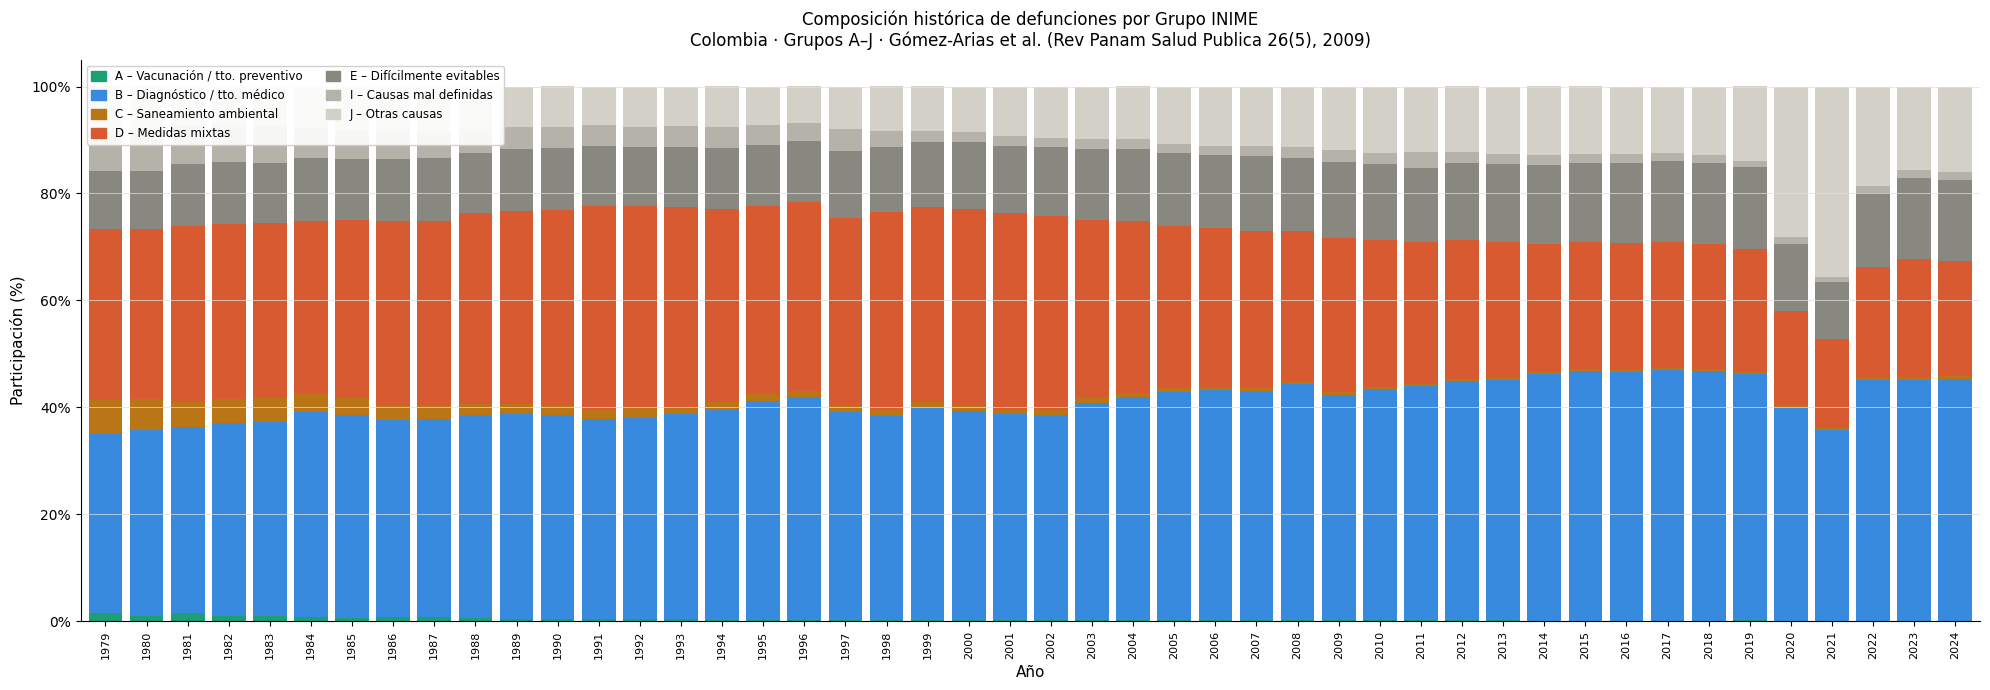

[INFO] Gráfica generada correctamente.


/tmp/ipykernel_55/1061995356.py:127: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_color, subset=["Atribuible S.S. A+B (%)"])


Año,Atribuible S.S. A+B (%),No atribuible C–J (%),Total fallecidos
1979,35.0 %,65.0 %,1.654
1980,35.8 %,64.2 %,1.305
1981,36.2 %,63.8 %,2.115
1982,37.0 %,63.0 %,1.491
1983,37.3 %,62.7 %,1.267
1984,39.2 %,60.8 %,1.120
1985,38.5 %,61.5 %,1.092
1986,37.6 %,62.4 %,1.102
1987,37.8 %,62.2 %,1.147
1988,38.6 %,61.4 %,828


[INFO] Tabla de participación generada correctamente.


In [17]:
# =============================================================================
# SECCIÓN 6: EJECUCIÓN SECCIÓN 4 + 5
# =============================================================================

# Ejecutar de forma independiente al pipeline principal:

df_resumen_inime = resumen_atribuibilidad_detalle(df_defunciones_atribuibles)
display(df_resumen_inime.head(20))
graficar_composicion_inime(df_resumen_inime)